# Compare ROOT amplitude magnitudes and phases

This notebook compares the corresponding fitted amplitude magnitudes and phases from two ROOT files.

It applies a ROOT-side `RDataFrame.Filter(...)` cut on `log_val` before reading the amplitude branches. Edit `CUT1` and `CUT2` in the configuration cell below.

In [617]:
from pathlib import Path
import re
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Configuration

Edit the file paths, tree names, and `log_val` cuts here.

Use an empty string `""` for no cut.

Examples:

```python
CUT1 = "log_val < -100"
CUT2 = "log_val > -200 && log_val < -100"
```

In [618]:
# Input ROOT files
FILE1 = Path("/home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/OutputFiles/test.root")
FILE2 = Path("/home/dleahy27/Desktop/PhD/brufit/tutorials/ElectroAmps/TwoSpin0AmpsFromMoments/resultsGivenMoments_muRhoLastBin.root")

# Explicit tree names.
# Set to None to auto-detect the first TTree in each file.
TREE1 = "fitResults"
TREE2 = "PartialWaves"

# ROOT-side cuts.
# Use C++/ROOT syntax: &&, ||, <, >, <=, >=
# Leave as "" for no cut.
CUT1 = "log_val<=0.12"   # e.g. "log_val < -100"
CUT2 = "log_val<=2.72"   # e.g. "log_val < -80"

# Output directory
OUTDIR = Path("outputs/amplitude_comparison")
OUTDIR.mkdir(parents=True, exist_ok=True)

print("FILE1:", FILE1)
print("FILE2:", FILE2)
print("TREE1:", TREE1)
print("TREE2:", TREE2)
print("CUT1:", CUT1 if CUT1 else "<none>")
print("CUT2:", CUT2 if CUT2 else "<none>")

FILE1: /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/OutputFiles/test.root
FILE2: /home/dleahy27/Desktop/PhD/brufit/tutorials/ElectroAmps/TwoSpin0AmpsFromMoments/resultsGivenMoments_muRhoLastBin.root
TREE1: fitResults
TREE2: PartialWaves
CUT1: log_val<=0.12
CUT2: log_val<=2.72


In [619]:
def read_root_tree_with_root_cut(path, tree_name=None, cut=""):
    '''
    Read only scalar amplitude/phase branches after applying a ROOT-side cut.

    Parameters
    ----------
    path : str or Path
        ROOT file path.
    tree_name : str or None
        TTree name. If None, the first TTree is auto-detected.
    cut : str
        ROOT/RDataFrame filter expression, e.g.
            "log_val < -100"
            "log_val > -200 && log_val < -100"
        Use "" for no cut.

    Returns
    -------
    pd.DataFrame
        One row per surviving entry, columns are scalar amplitude/phase branches.
    '''
    import ROOT

    path = Path(path)

    f = ROOT.TFile.Open(str(path))
    if not f or f.IsZombie():
        raise OSError(f"Could not open ROOT file: {path}")

    if tree_name is None:
        found_tree = None
        for key in f.GetListOfKeys():
            obj = key.ReadObj()
            if obj.InheritsFrom("TTree"):
                found_tree = obj.GetName()
                break

        if found_tree is None:
            f.Close()
            raise ValueError(f"No TTree found in {path}")

        tree_name = found_tree

    tree = f.Get(tree_name)
    if not tree:
        f.Close()
        raise ValueError(f"Tree '{tree_name}' not found in {path}")

    branch_names = [br.GetName() for br in tree.GetListOfBranches()]
    selected = amplitude_like_branches(branch_names)

    if not selected:
        preview = ", ".join(branch_names[:50])
        f.Close()
        raise ValueError(
            f"No amplitude/phase branches found in {path}:{tree_name}. "
            f"First branches are: {preview}"
        )

    if cut and cut.strip() and "log_val" not in branch_names:
        f.Close()
        raise ValueError(f"Cut requested, but 'log_val' was not found in {path}:{tree_name}")

    f.Close()

    # ROOT-side filtering.
    rdf = ROOT.RDataFrame(tree_name, str(path))

    n_before = int(rdf.Count().GetValue())

    if cut and cut.strip():
        rdf = rdf.Filter(cut)

    n_after = int(rdf.Count().GetValue())

    print(f"{path.name}:{tree_name}")
    print(f"  cut: {cut if cut and cut.strip() else '<none>'}")
    print(f"  entries: {n_before} -> {n_after}")

    if n_after == 0:
        raise ValueError(f"No entries survived the cut for {path}:{tree_name}")

    # Read only selected scalar amplitude/phase branches after the cut.
    arrays = rdf.AsNumpy(selected)

    data = {}
    for br in selected:
        arr = np.asarray(arrays[br])

        # Reject true vector/jagged branches.
        # If a branch somehow comes back as object, only keep it if entries are scalar-convertible.
        if arr.dtype == object:
            try:
                arr = np.asarray([float(x) for x in arr], dtype=float)
            except Exception:
                continue

        if arr.ndim == 1:
            data[br] = arr.astype(float)
        elif arr.ndim == 2 and arr.shape[1] == 1:
            data[br] = arr[:, 0].astype(float)

    if not data:
        raise ValueError(f"No usable scalar amplitude/phase branches survived in {path}:{tree_name}")

    # Safety check: keep only the most common column length.
    lengths = {k: len(v) for k, v in data.items()}
    target_len = max(set(lengths.values()), key=list(lengths.values()).count)
    dropped = [k for k, v in lengths.items() if v != target_len]

    if dropped:
        print("  warning: dropped unequal-length branches:", dropped)

    data = {k: v for k, v in data.items() if len(v) == target_len}

    return pd.DataFrame(data)

## Branch selection helpers

In [620]:
# Matches names like:
#   a_T_0_0, b_T_1_1, a_L_2_m1, b_L_2_-1
#   aphi_T_1_1, bphi_L_2_m1, aphi_T_2_-1
MAG_RE = re.compile(r"^[ab]_[TL]_\d+_(?:m?\d+|-?\d+)$")
PHASE_RE = re.compile(r"^[ab]phi_[TL]_\d+_(?:m?\d+|-?\d+)$")


def is_magnitude_branch(name):
    return bool(MAG_RE.match(str(name)))

def is_phase_branch(name):
    return bool(PHASE_RE.match(str(name)))

def amplitude_like_branches(branch_names):
    out = []
    for br in branch_names:
        br = str(br).split(";")[0]
        if is_magnitude_branch(br) or is_phase_branch(br):
            out.append(br)
    return sorted(set(out))

def phase_name_from_magnitude(mag_name):
    # a_T_1_1 -> aphi_T_1_1
    # b_L_2_m1 -> bphi_L_2_m1
    refl, rest = mag_name[0], mag_name[1:]
    return f"{refl}phi{rest}"

def magnitude_name_from_phase(phase_name):
    # aphi_T_1_1 -> a_T_1_1
    # bphi_L_2_m1 -> b_L_2_m1
    if phase_name.startswith("aphi"):
        return "a" + phase_name[len("aphi"):]
    if phase_name.startswith("bphi"):
        return "b" + phase_name[len("bphi"):]
    return None

def sort_amplitude_name(name):
    # Sort in a stable physics-like order: a before b, T before L, then l, then m.
    # Works with m encoded as "m1" or "-1".
    parts = name.split("_")
    try:
        refl = parts[0]
        orient = parts[1]
        ell = int(parts[2])
        m_raw = parts[3]
        if m_raw.startswith("m"):
            m = -int(m_raw[1:])
        else:
            m = int(m_raw)
        return (0 if refl == "a" else 1, 0 if orient == "T" else 1, ell, m)
    except Exception:
        return (999, 999, 999, 999, name)

## Read ROOT trees after a ROOT-side `log_val` cut

This uses `ROOT.RDataFrame.Filter(...)`, so the cut is applied before the data are converted into NumPy/Pandas arrays.

## Read both files

In [621]:
df1 = read_root_tree_with_root_cut(FILE1, TREE1, CUT1)
df2 = read_root_tree_with_root_cut(FILE2, TREE2, CUT2)

print()
print("df1 shape:", df1.shape)
print("df2 shape:", df2.shape)

display(df1.head())
display(df2.head())

test.root:fitResults
  cut: log_val<=0.12
  entries: 10000 -> 285
resultsGivenMoments_muRhoLastBin.root:PartialWaves
  cut: log_val<=2.72
  entries: 10000 -> 590

df1 shape: (285, 28)
df2 shape: (590, 16)


,a_L_0_0,a_L_1_0,a_L_1_1,a_T_0_0,a_T_1_0,a_T_1_1,a_T_1_m1,aphi_L_0_0,aphi_L_1_0,aphi_L_1_1,...,b_T_1_0,b_T_1_1,b_T_1_m1,bphi_L_0_0,bphi_L_1_0,bphi_L_1_1,bphi_T_0_0,bphi_T_1_0,bphi_T_1_1,bphi_T_1_m1
0,0.0,0.709638,0.015540,0.0,0.143156,0.688426,0.031634,0.0,-0.240018,-2.251464,...,0.018348,0.112076,0.059366,0.0,0.0,-1.227295,0.0,-1.326461,0.0,-2.693084
1,0.0,0.709641,0.015531,0.0,0.143157,0.688427,0.031632,0.0,-0.240023,-2.252090,...,0.018355,0.112081,0.059353,0.0,0.0,-1.227373,0.0,-1.324603,0.0,-2.693059
2,0.0,0.709641,0.015528,0.0,0.143157,0.688429,0.031630,0.0,-0.240037,-2.252164,...,0.018353,0.112096,0.059345,0.0,0.0,-1.227382,0.0,-1.324840,0.0,-2.693040
3,0.0,0.709637,0.015530,0.0,0.143157,0.688430,0.031637,0.0,-0.240024,-2.252239,...,0.018356,0.112094,0.059336,0.0,0.0,-1.227414,0.0,-1.323202,0.0,-2.693061
4,0.0,0.709640,0.015530,0.0,0.143157,0.688427,0.031634,0.0,-0.240026,-2.252123,...,0.018350,0.112082,0.059352,0.0,0.0,-1.227370,0.0,-1.325479,0.0,-2.693133


,a_L_1_0,a_L_1_1,a_T_1_0,a_T_1_1,a_T_1_m1,aphi_L_1_0,aphi_L_1_1,aphi_T_1_0,aphi_T_1_m1,b_L_1_1,b_T_1_0,b_T_1_1,b_T_1_m1,bphi_L_1_1,bphi_T_1_0,bphi_T_1_m1
0,0.708690,0.017116,0.143810,0.688648,0.031276,-0.239181,-2.113406,-0.114390,-2.561011,0.139482,0.018384,0.112479,0.059586,-1.204548,-1.047496,-2.706019
1,0.708682,0.017111,0.143811,0.688660,0.031280,-0.239173,-2.113713,-0.114428,-2.560731,0.139469,0.018405,0.112486,0.059568,-1.204560,-1.047577,-2.705804
2,0.708688,0.017117,0.143810,0.688657,0.031272,-0.239187,-2.113409,-0.114387,-2.561066,0.139462,0.018387,0.112500,0.059546,-1.204594,-1.047477,-2.705833
3,0.708689,0.017124,0.143812,0.688659,0.031270,-0.239184,-2.112709,-0.114378,-2.561032,0.139451,0.018390,0.112508,0.059547,-1.204668,-1.044929,-2.705719
4,0.708689,0.017112,0.143810,0.688657,0.031276,-0.239186,-2.113664,-0.114389,-2.560801,0.139463,0.018393,0.112494,0.059548,-1.204575,-1.047345,-2.705862


## Statistical helpers

Phases are handled with circular means and circular standard deviations.

In [622]:
def ordinary_mean_std(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return np.nan, np.nan
    if len(x) == 1:
        return float(x[0]), 0.0
    return float(np.mean(x)), float(np.std(x, ddof=1))

def wrap_to_pi(angle):
    return (angle + np.pi) % (2.0 * np.pi) - np.pi

def circular_mean_std(phi):
    phi = np.asarray(phi, dtype=float)
    phi = phi[np.isfinite(phi)]

    if len(phi) == 0:
        return np.nan, np.nan

    if len(phi) == 1:
        return float(wrap_to_pi(phi[0])), 0.0

    c = np.mean(np.cos(phi))
    s = np.mean(np.sin(phi))

    mean = math.atan2(s, c)

    R = np.hypot(c, s)
    R = min(max(R, 1e-15), 1.0)

    # Circular standard deviation in radians.
    std = np.sqrt(-2.0 * np.log(R))

    return float(wrap_to_pi(mean)), float(std)

def combined_error(std1, std2):
    if not np.isfinite(std1) or not np.isfinite(std2):
        return np.nan
    return float(np.sqrt(std1**2 + std2**2))

def safe_pull(delta, err):
    if not np.isfinite(delta) or not np.isfinite(err) or err <= 0:
        return np.nan
    return float(delta / err)

## Build comparison table

In [623]:
mag_cols1 = {c for c in df1.columns if is_magnitude_branch(c)}
mag_cols2 = {c for c in df2.columns if is_magnitude_branch(c)}

common_mags = sorted(mag_cols1 & mag_cols2, key=sort_amplitude_name)

print(f"Common magnitudes: {len(common_mags)}")
print(common_mags)

Common magnitudes: 9
['a_T_1_m1', 'a_T_1_0', 'a_T_1_1', 'a_L_1_0', 'a_L_1_1', 'b_T_1_m1', 'b_T_1_0', 'b_T_1_1', 'b_L_1_1']


In [624]:
def compare_amplitudes(df1, df2, common_mags, fixed_missing_phases_to_zero=True):
    rows = []

    for mag in common_mags:
        phase = phase_name_from_magnitude(mag)

        # Magnitudes
        mean1, std1 = ordinary_mean_std(df1[mag].to_numpy())
        mean2, std2 = ordinary_mean_std(df2[mag].to_numpy())

        delta = mean2 - mean1
        err = combined_error(std1, std2)
        pull = safe_pull(delta, err)

        rows.append({
            "amplitude": mag,
            "kind": "magnitude",
            "parameter": mag,
            "file1_mean": mean1,
            "file1_std": std1,
            "file2_mean": mean2,
            "file2_std": std2,
            "delta_file2_minus_file1": delta,
            "combined_std": err,
            "pull": pull,
            "file1_n": int(df1[mag].notna().sum()),
            "file2_n": int(df2[mag].notna().sum()),
        })

        # Phases
        phase1_exists = phase in df1.columns
        phase2_exists = phase in df2.columns

        if phase1_exists:
            ph_mean1, ph_std1 = circular_mean_std(df1[phase].to_numpy())
            ph_n1 = int(df1[phase].notna().sum())
        elif fixed_missing_phases_to_zero:
            ph_mean1, ph_std1 = 0.0, 0.0
            ph_n1 = len(df1)
        else:
            ph_mean1, ph_std1 = np.nan, np.nan
            ph_n1 = 0

        if phase2_exists:
            ph_mean2, ph_std2 = circular_mean_std(df2[phase].to_numpy())
            ph_n2 = int(df2[phase].notna().sum())
        elif fixed_missing_phases_to_zero:
            ph_mean2, ph_std2 = 0.0, 0.0
            ph_n2 = len(df2)
        else:
            ph_mean2, ph_std2 = np.nan, np.nan
            ph_n2 = 0

        ph_delta = wrap_to_pi(ph_mean2 - ph_mean1)
        ph_err = combined_error(ph_std1, ph_std2)
        ph_pull = safe_pull(ph_delta, ph_err)

        rows.append({
            "amplitude": mag,
            "kind": "phase",
            "parameter": phase,
            "file1_mean": ph_mean1,
            "file1_std": ph_std1,
            "file2_mean": ph_mean2,
            "file2_std": ph_std2,
            "delta_file2_minus_file1": ph_delta,
            "combined_std": ph_err,
            "pull": ph_pull,
            "file1_n": ph_n1,
            "file2_n": ph_n2,
        })

    return pd.DataFrame(rows)

comparison = compare_amplitudes(df1, df2, common_mags)

csv_path = OUTDIR / "amplitude_parameter_comparison.csv"
comparison.to_csv(csv_path, index=False)

print(f"Wrote: {csv_path}")
display(comparison)

Wrote: amplitude_comparison_output/amplitude_parameter_comparison.csv


,amplitude,kind,parameter,file1_mean,file1_std,file2_mean,file2_std,delta_file2_minus_file1,combined_std,pull,file1_n,file2_n
0,a_T_1_m1,magnitude,a_T_1_m1,0.031634,3.599152e-06,0.031275,0.000058,-0.000359,0.000058,-6.198584,285,590
1,a_T_1_m1,phase,aphi_T_1_m1,-2.550447,1.586225e-04,-2.560977,0.001677,-0.010530,0.001685,-6.250145,285,590
2,a_T_1_0,magnitude,a_T_1_0,0.143157,9.493314e-07,0.143810,0.000006,0.000653,0.000006,104.744192,285,590
3,a_T_1_0,phase,aphi_T_1_0,-0.123306,2.432549e-05,-0.114404,0.000284,0.008901,0.000285,31.182666,285,590
4,a_T_1_1,magnitude,a_T_1_1,0.688427,1.430542e-06,0.688657,0.000018,0.000230,0.000018,12.955574,285,590
5,a_T_1_1,phase,aphi_T_1_1,0.000000,-0.000000e+00,0.000000,0.000000,0.000000,0.000000,NaN,285,590
6,a_L_1_0,magnitude,a_L_1_0,0.709641,1.365852e-06,0.708689,0.000041,-0.000953,0.000041,-23.009478,285,590
7,a_L_1_0,phase,aphi_L_1_0,-0.240021,8.233306e-06,-0.239190,0.000126,0.000831,0.000126,6.582182,285,590
8,a_L_1_1,magnitude,a_L_1_1,0.015531,5.408213e-06,0.017115,0.000091,0.001584,0.000092,17.311273,285,590
9,a_L_1_1,phase,aphi_L_1_1,-2.252074,2.768042e-04,-2.113535,0.003749,0.138539,0.003759,36.854601,285,590


## Magnitude comparison plot

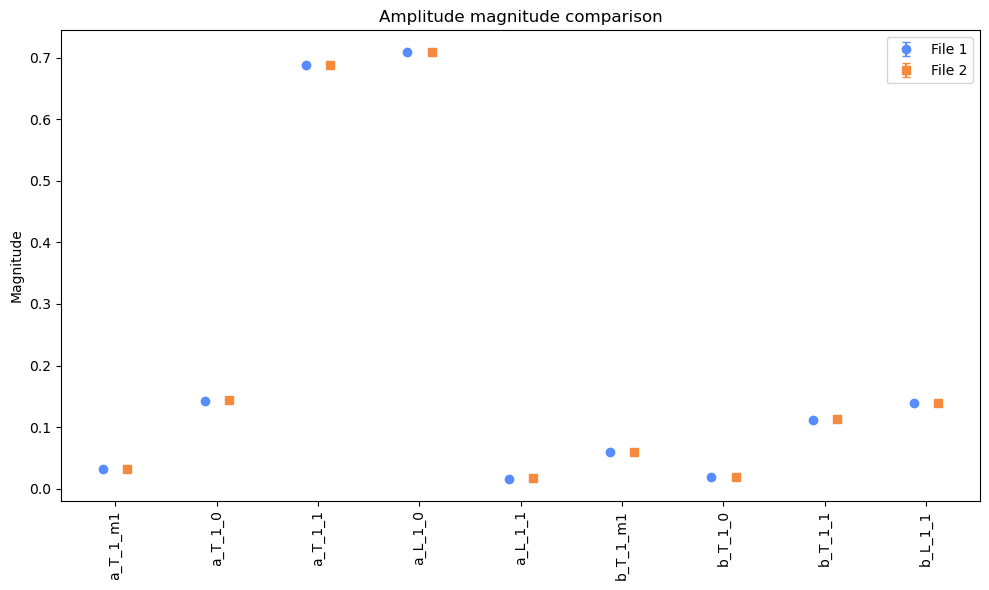

Wrote: amplitude_comparison_output/magnitude_comparison.png


In [625]:
mag_comp = comparison[comparison["kind"] == "magnitude"].copy()
mag_comp = mag_comp.sort_values("amplitude", key=lambda s: s.map(sort_amplitude_name))

x = np.arange(len(mag_comp))

plt.figure(figsize=(max(10, 0.45 * len(mag_comp)), 6))
plt.errorbar(
    x - 0.12,
    mag_comp["file1_mean"],
    yerr=mag_comp["file1_std"],
    fmt="o",
    capsize=3,
    label="File 1"
)
plt.errorbar(
    x + 0.12,
    mag_comp["file2_mean"],
    yerr=mag_comp["file2_std"],
    fmt="s",
    capsize=3,
    label="File 2"
)
plt.xticks(x, mag_comp["amplitude"], rotation=90)
plt.ylabel("Magnitude")
plt.title("Amplitude magnitude comparison")
plt.legend()
plt.tight_layout()

mag_plot = OUTDIR / "magnitude_comparison.png"
plt.savefig(mag_plot, dpi=200)
plt.show()

print(f"Wrote: {mag_plot}")

## Magnitude Difference

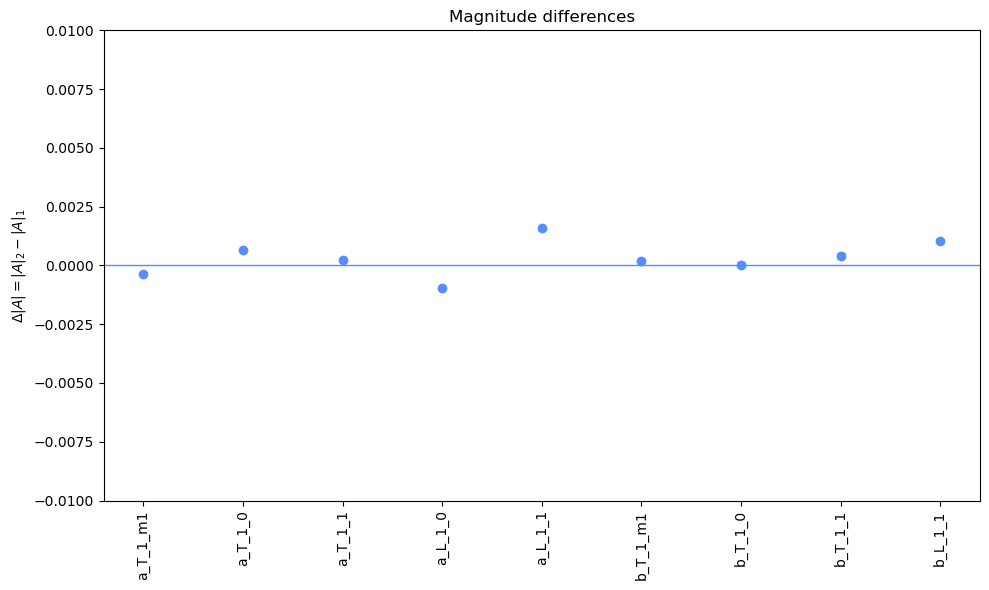

Wrote: amplitude_comparison_output/magnitude_differences.png


,amplitude,parameter,file1_mean,file1_std,file2_mean,file2_std,delta_mag,delta_mag_err,pull
0,a_T_1_m1,a_T_1_m1,0.031634,3.599152e-06,0.031275,0.000058,-0.000359,0.000058,-6.198584
2,a_T_1_0,a_T_1_0,0.143157,9.493314e-07,0.143810,0.000006,0.000653,0.000006,104.744192
4,a_T_1_1,a_T_1_1,0.688427,1.430542e-06,0.688657,0.000018,0.000230,0.000018,12.955574
6,a_L_1_0,a_L_1_0,0.709641,1.365852e-06,0.708689,0.000041,-0.000953,0.000041,-23.009478
8,a_L_1_1,a_L_1_1,0.015531,5.408213e-06,0.017115,0.000091,0.001584,0.000092,17.311273
10,b_T_1_m1,b_T_1_m1,0.059353,7.502492e-06,0.059544,0.000074,0.000191,0.000075,2.564410
12,b_T_1_0,b_T_1_0,0.018359,9.528914e-06,0.018387,0.000098,0.000028,0.000098,0.280374
14,b_T_1_1,b_T_1_1,0.112081,7.147815e-06,0.112499,0.000089,0.000418,0.000090,4.666243
16,b_L_1_1,b_L_1_1,0.138415,5.335933e-06,0.139463,0.000061,0.001048,0.000061,17.038259


In [626]:
# Magnitude difference plot: |A|_2 - |A|_1

mag_diff = comparison[comparison["kind"] == "magnitude"].copy()
mag_diff = mag_diff.sort_values("amplitude", key=lambda s: s.map(sort_amplitude_name))

mag_diff["delta_mag"] = mag_diff["delta_file2_minus_file1"]
mag_diff["delta_mag_err"] = mag_diff["combined_std"]

x = np.arange(len(mag_diff))

plt.figure(figsize=(max(10, 0.45 * len(mag_diff)), 6))

plt.axhline(0.0, linewidth=1)

plt.errorbar(
    x,
    mag_diff["delta_mag"],
    yerr=mag_diff["delta_mag_err"],
    fmt="o",
    capsize=3,
)

plt.xticks(x, mag_diff["parameter"], rotation=90)
plt.ylabel(r"$\Delta |A| = |A|_2 - |A|_1$")
plt.title("Magnitude differences")
ax = plt.gca()
ax.set_ylim(-0.01, 0.01)
plt.tight_layout()

mag_diff_plot = OUTDIR / "magnitude_differences.png"
plt.savefig(mag_diff_plot, dpi=200)
plt.show()


print(f"Wrote: {mag_diff_plot}")

display(
    mag_diff[
        [
            "amplitude",
            "parameter",
            "file1_mean",
            "file1_std",
            "file2_mean",
            "file2_std",
            "delta_mag",
            "delta_mag_err",
            "pull",
        ]
    ]
)

## Phase comparison plot

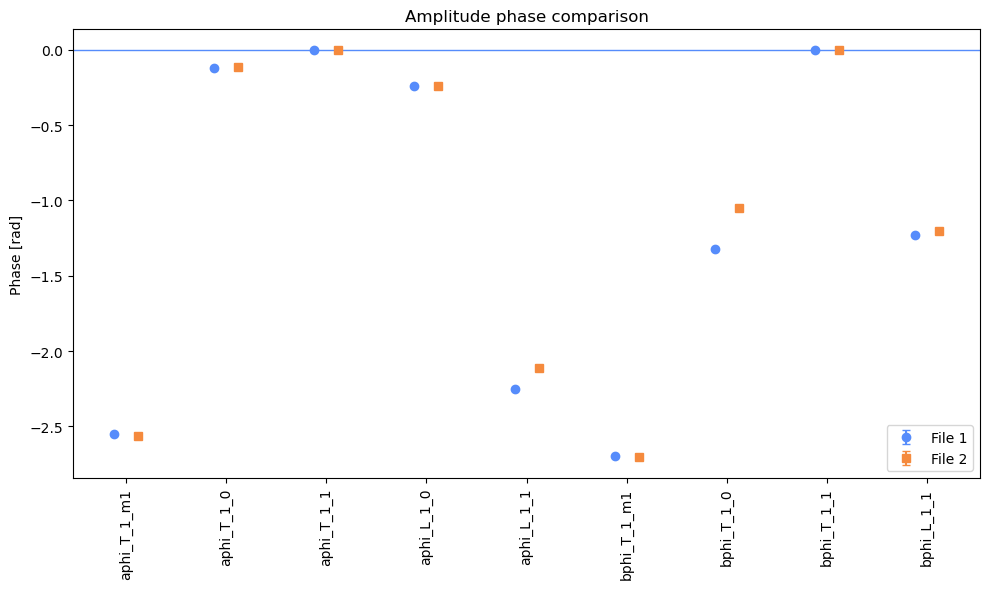

Wrote: amplitude_comparison_output/phase_comparison.png


In [627]:
phase_comp = comparison[comparison["kind"] == "phase"].copy()
phase_comp = phase_comp.sort_values("amplitude", key=lambda s: s.map(sort_amplitude_name))

x = np.arange(len(phase_comp))

plt.figure(figsize=(max(10, 0.45 * len(phase_comp)), 6))
plt.errorbar(
    x - 0.12,
    phase_comp["file1_mean"],
    yerr=phase_comp["file1_std"],
    fmt="o",
    capsize=3,
    label="File 1"
)
plt.errorbar(
    x + 0.12,
    phase_comp["file2_mean"],
    yerr=phase_comp["file2_std"],
    fmt="s",
    capsize=3,
    label="File 2"
)
plt.axhline(0.0, linewidth=1)
plt.xticks(x, phase_comp["parameter"], rotation=90)
plt.ylabel("Phase [rad]")
plt.title("Amplitude phase comparison")
plt.legend()
plt.tight_layout()

phase_plot = OUTDIR / "phase_comparison.png"
plt.savefig(phase_plot, dpi=200)
plt.show()

print(f"Wrote: {phase_plot}")

## Phase Differences Plot

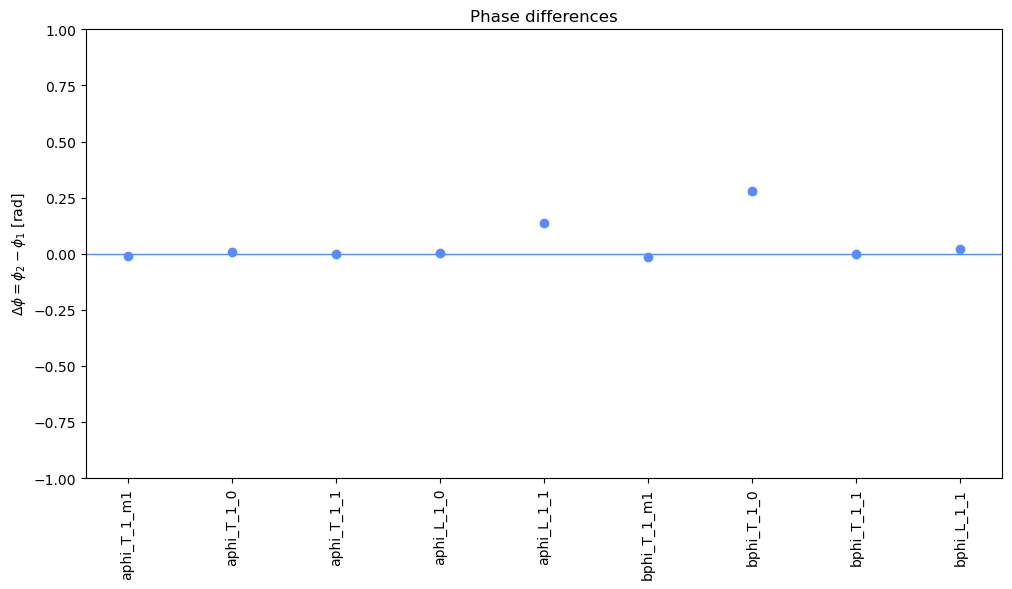

Wrote: amplitude_comparison_output/phase_differences.png


,amplitude,parameter,file1_mean,file1_std,file2_mean,file2_std,delta_phase,delta_phase_err,pull
1,a_T_1_m1,aphi_T_1_m1,-2.550447,0.000159,-2.560977,0.001677,-0.010530,0.001685,-6.250145
3,a_T_1_0,aphi_T_1_0,-0.123306,0.000024,-0.114404,0.000284,0.008901,0.000285,31.182666
5,a_T_1_1,aphi_T_1_1,0.000000,-0.000000,0.000000,0.000000,0.000000,0.000000,NaN
7,a_L_1_0,aphi_L_1_0,-0.240021,0.000008,-0.239190,0.000126,0.000831,0.000126,6.582182
9,a_L_1_1,aphi_L_1_1,-2.252074,0.000277,-2.113535,0.003749,0.138539,0.003759,36.854601
11,b_T_1_m1,bphi_T_1_m1,-2.693077,0.000091,-2.705885,0.001150,-0.012808,0.001154,-11.101472
13,b_T_1_0,bphi_T_1_0,-1.325644,0.000542,-1.047844,0.011026,0.277800,0.011040,25.163879
15,b_T_1_1,bphi_T_1_1,0.000000,-0.000000,0.000000,0.000000,0.000000,0.000000,NaN
17,b_L_1_1,bphi_L_1_1,-1.227372,0.000043,-1.204635,0.000557,0.022737,0.000558,40.719555


In [628]:
# Phase difference plot: phi_2 - phi_1, wrapped to (-pi, pi]

phase_diff = comparison[comparison["kind"] == "phase"].copy()
phase_diff = phase_diff.sort_values("amplitude", key=lambda s: s.map(sort_amplitude_name))

# Already wrapped in compare_amplitudes(...)
phase_diff["delta_phase"] = phase_diff["delta_file2_minus_file1"]
phase_diff["delta_phase_err"] = phase_diff["combined_std"]

x = np.arange(len(phase_diff))

plt.figure(figsize=(max(10, 0.45 * len(phase_diff)), 6))

plt.axhline(0.0, linewidth=1)
plt.axhline(np.pi, linestyle=":", linewidth=1)
plt.axhline(-np.pi, linestyle=":", linewidth=1)

plt.errorbar(
    x,
    phase_diff["delta_phase"],
    yerr=phase_diff["delta_phase_err"],
    fmt="o",
    capsize=3,
)
plt.xticks(x, phase_diff["parameter"], rotation=90)
plt.ylabel(r"$\Delta \phi = \phi_2 - \phi_1$ [rad]")
plt.title(r"Phase differences")
plt.tight_layout()
ax = plt.gca()
ax.set_ylim(-1, 1)

phase_diff_plot = OUTDIR / "phase_differences.png"
plt.savefig(phase_diff_plot, dpi=200)
plt.show()

print(f"Wrote: {phase_diff_plot}")

display(
    phase_diff[
        [
            "amplitude",
            "parameter",
            "file1_mean",
            "file1_std",
            "file2_mean",
            "file2_std",
            "delta_phase",
            "delta_phase_err",
            "pull",
        ]
    ]
)

## Pull plot

The pull is defined as

\[
\mathrm{pull} = \frac{\bar{x}_2 - \bar{x}_1}{\sqrt{\sigma_1^2+\sigma_2^2}}.
\]

For phases, the difference is wrapped to \((-\pi,\pi]\).

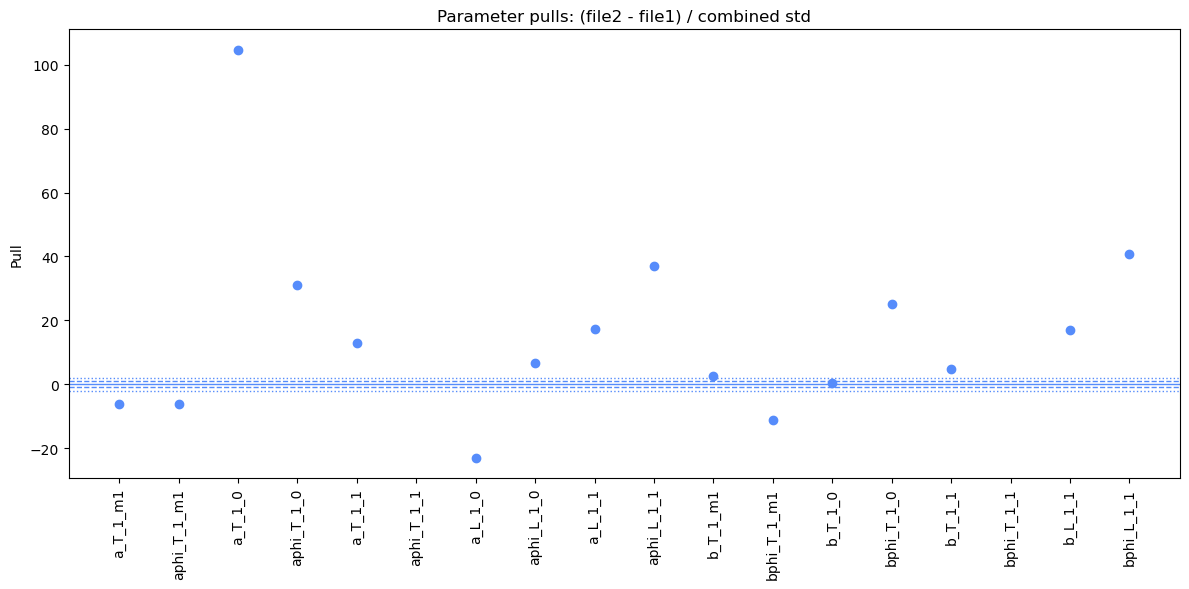

Wrote: amplitude_comparison_output/parameter_pulls.png


In [629]:
pull_comp = comparison.copy()
pull_comp["label"] = pull_comp["parameter"]

pull_comp = pull_comp.sort_values(
    ["amplitude", "kind"],
    key=lambda s: s.map(lambda x: sort_amplitude_name(x) if isinstance(x, str) else x)
)

x = np.arange(len(pull_comp))

plt.figure(figsize=(max(12, 0.35 * len(pull_comp)), 6))
plt.axhline(0.0, linewidth=1)
plt.axhline(1.0, linestyle="--", linewidth=1)
plt.axhline(-1.0, linestyle="--", linewidth=1)
plt.axhline(2.0, linestyle=":", linewidth=1)
plt.axhline(-2.0, linestyle=":", linewidth=1)
plt.plot(x, pull_comp["pull"], "o")
plt.xticks(x, pull_comp["label"], rotation=90)
plt.ylabel("Pull")
plt.title("Parameter pulls: (file2 - file1) / combined std")
plt.tight_layout()

pull_plot = OUTDIR / "parameter_pulls.png"
plt.savefig(pull_plot, dpi=200)
plt.show()

print(f"Wrote: {pull_plot}")

## Largest discrepancies

In [630]:
largest = comparison.copy()
largest["abs_pull"] = largest["pull"].abs()
largest = largest.sort_values("abs_pull", ascending=False)

display(largest.head(30))

,amplitude,kind,parameter,file1_mean,file1_std,file2_mean,file2_std,delta_file2_minus_file1,combined_std,pull,file1_n,file2_n,abs_pull
2,a_T_1_0,magnitude,a_T_1_0,0.143157,9.493314e-07,0.143810,0.000006,0.000653,0.000006,104.744192,285,590,104.744192
17,b_L_1_1,phase,bphi_L_1_1,-1.227372,4.288935e-05,-1.204635,0.000557,0.022737,0.000558,40.719555,285,590,40.719555
9,a_L_1_1,phase,aphi_L_1_1,-2.252074,2.768042e-04,-2.113535,0.003749,0.138539,0.003759,36.854601,285,590,36.854601
3,a_T_1_0,phase,aphi_T_1_0,-0.123306,2.432549e-05,-0.114404,0.000284,0.008901,0.000285,31.182666,285,590,31.182666
13,b_T_1_0,phase,bphi_T_1_0,-1.325644,5.416915e-04,-1.047844,0.011026,0.277800,0.011040,25.163879,285,590,25.163879
6,a_L_1_0,magnitude,a_L_1_0,0.709641,1.365852e-06,0.708689,0.000041,-0.000953,0.000041,-23.009478,285,590,23.009478
8,a_L_1_1,magnitude,a_L_1_1,0.015531,5.408213e-06,0.017115,0.000091,0.001584,0.000092,17.311273,285,590,17.311273
16,b_L_1_1,magnitude,b_L_1_1,0.138415,5.335933e-06,0.139463,0.000061,0.001048,0.000061,17.038259,285,590,17.038259
4,a_T_1_1,magnitude,a_T_1_1,0.688427,1.430542e-06,0.688657,0.000018,0.000230,0.000018,12.955574,285,590,12.955574
11,b_T_1_m1,phase,bphi_T_1_m1,-2.693077,9.138270e-05,-2.705885,0.001150,-0.012808,0.001154,-11.101472,285,590,11.101472


## Complex amplitude comparison

This section combines each magnitude and phase into the complex amplitude

\[
A = |A| e^{i\phi},
\]

then compares the actual complex values from the two files:

\[
\Delta A = A_2 - A_1.
\]

This is often more useful than comparing magnitudes and phases separately, because a small phase shift on a large amplitude can be important in the complex plane.

In [631]:
def get_comparison_value(comp, amplitude, kind, column):
    rows = comp[(comp["amplitude"] == amplitude) & (comp["kind"] == kind)]
    if len(rows) == 0:
        return np.nan
    return rows.iloc[0][column]

def build_complex_amplitude_comparison(comparison, common_mags):
    rows = []

    for amp in common_mags:
        mag1 = get_comparison_value(comparison, amp, "magnitude", "file1_mean")
        mag2 = get_comparison_value(comparison, amp, "magnitude", "file2_mean")

        mag1_std = get_comparison_value(comparison, amp, "magnitude", "file1_std")
        mag2_std = get_comparison_value(comparison, amp, "magnitude", "file2_std")

        phi1 = get_comparison_value(comparison, amp, "phase", "file1_mean")
        phi2 = get_comparison_value(comparison, amp, "phase", "file2_mean")

        phi1_std = get_comparison_value(comparison, amp, "phase", "file1_std")
        phi2_std = get_comparison_value(comparison, amp, "phase", "file2_std")

        z1 = mag1 * np.exp(1j * phi1)
        z2 = mag2 * np.exp(1j * phi2)
        dz = z2 - z1

        abs_dz = np.abs(dz)
        arg_dz = wrap_to_pi(np.angle(dz)) if np.isfinite(np.real(dz)) and np.isfinite(np.imag(dz)) else np.nan

        # Relative difference is normalised to file 1 amplitude size.
        # Undefined if file 1 amplitude is zero.
        rel_abs_dz = abs_dz / np.abs(z1) if np.abs(z1) > 0 else np.nan

        # First-order uncertainty estimate for Re/Im from magnitude/phase stds.
        # For A = r exp(i phi):
        #   sigma_Re^2 ≈ (cos phi sigma_r)^2 + (-r sin phi sigma_phi)^2
        #   sigma_Im^2 ≈ (sin phi sigma_r)^2 + ( r cos phi sigma_phi)^2
        def real_imag_errors(r, phi, sr, sphi):
            if not all(np.isfinite(x) for x in [r, phi, sr, sphi]):
                return np.nan, np.nan
            sig_re = np.sqrt((np.cos(phi) * sr)**2 + (-r * np.sin(phi) * sphi)**2)
            sig_im = np.sqrt((np.sin(phi) * sr)**2 + ( r * np.cos(phi) * sphi)**2)
            return sig_re, sig_im

        z1_re_err, z1_im_err = real_imag_errors(mag1, phi1, mag1_std, phi1_std)
        z2_re_err, z2_im_err = real_imag_errors(mag2, phi2, mag2_std, phi2_std)

        dz_re_err = combined_error(z1_re_err, z2_re_err)
        dz_im_err = combined_error(z1_im_err, z2_im_err)

        dz_re_pull = safe_pull(np.real(dz), dz_re_err)
        dz_im_pull = safe_pull(np.imag(dz), dz_im_err)

        rows.append({
            "amplitude": amp,

            "file1_mag": mag1,
            "file1_phase": phi1,
            "file1_real": np.real(z1),
            "file1_imag": np.imag(z1),
            "file1_real_std_est": z1_re_err,
            "file1_imag_std_est": z1_im_err,

            "file2_mag": mag2,
            "file2_phase": phi2,
            "file2_real": np.real(z2),
            "file2_imag": np.imag(z2),
            "file2_real_std_est": z2_re_err,
            "file2_imag_std_est": z2_im_err,

            "delta_real": np.real(dz),
            "delta_imag": np.imag(dz),
            "delta_abs": abs_dz,
            "delta_arg": arg_dz,
            "relative_delta_abs": rel_abs_dz,

            "delta_real_std_est": dz_re_err,
            "delta_imag_std_est": dz_im_err,
            "delta_real_pull": dz_re_pull,
            "delta_imag_pull": dz_im_pull,
        })

    return pd.DataFrame(rows)

complex_comparison = build_complex_amplitude_comparison(comparison, common_mags)

complex_csv_path = OUTDIR / "complex_amplitude_comparison.csv"
complex_comparison.to_csv(complex_csv_path, index=False)

print(f"Wrote: {complex_csv_path}")
display(complex_comparison)

Wrote: amplitude_comparison_output/complex_amplitude_comparison.csv


,amplitude,file1_mag,file1_phase,file1_real,file1_imag,file1_real_std_est,file1_imag_std_est,file2_mag,file2_phase,file2_real,...,file2_imag_std_est,delta_real,delta_imag,delta_abs,delta_arg,relative_delta_abs,delta_real_std_est,delta_imag_std_est,delta_real_pull,delta_imag_pull
0,a_T_1_m1,0.031634,-2.550447,-0.026266,-0.017630,0.000004,0.000005,0.031275,-2.560977,-0.026150,...,0.000054,0.000116,0.000475,0.000489,1.330763,0.015445,0.000056,0.000054,2.058737,8.735454
1,a_T_1_0,0.143157,-0.123306,0.142070,-0.017607,0.000001,0.000003,0.143810,-0.114404,0.142870,...,0.000041,0.000800,0.001191,0.001435,0.979163,0.010021,0.000008,0.000041,102.971092,29.192980
2,a_T_1_1,0.688427,0.000000,0.688427,0.000000,0.000001,0.000000,0.688657,0.000000,0.688657,...,0.000000,0.000230,0.000000,0.000230,0.000000,0.000334,0.000018,0.000000,12.955574,NaN
3,a_L_1_0,0.709641,-0.240021,0.689298,-0.168698,0.000002,0.000006,0.708689,-0.239190,0.688512,...,0.000087,-0.000785,0.000799,0.001120,2.347773,0.001579,0.000045,0.000088,-17.274350,9.127617
4,a_L_1_1,0.015531,-2.252074,-0.009781,-0.012064,0.000005,0.000005,0.017115,-2.113535,-0.008840,...,0.000085,0.000942,-0.002592,0.002757,-1.222338,0.177541,0.000073,0.000085,12.972551,-30.454399
5,b_T_1_m1,0.059353,-2.693077,-0.053483,-0.025737,0.000007,0.000006,0.059544,-2.705885,-0.053981,...,0.000070,-0.000499,0.000606,0.000785,2.258991,0.013227,0.000074,0.000070,-6.778191,8.689590
6,b_T_1_0,0.018359,-1.325644,0.004456,-0.017810,0.000010,0.000010,0.018387,-1.047844,0.009183,...,0.000132,0.004727,0.001881,0.005088,0.378677,0.277120,0.000183,0.000132,25.887507,14.195481
7,b_T_1_1,0.112081,0.000000,0.112081,0.000000,0.000007,0.000000,0.112499,0.000000,0.112499,...,0.000000,0.000418,0.000000,0.000418,0.000000,0.003731,0.000090,0.000000,4.666243,NaN
8,b_L_1_1,0.138415,-1.227372,0.046606,-0.130333,0.000006,0.000005,0.139463,-1.204635,0.049933,...,0.000064,0.003326,0.000115,0.003328,0.034571,0.024045,0.000076,0.000064,43.783713,1.802350


## Complex-difference comparison plots

These show the size of the actual complex residuals \(|A_2-A_1|\), and optionally the real/imaginary pulls.

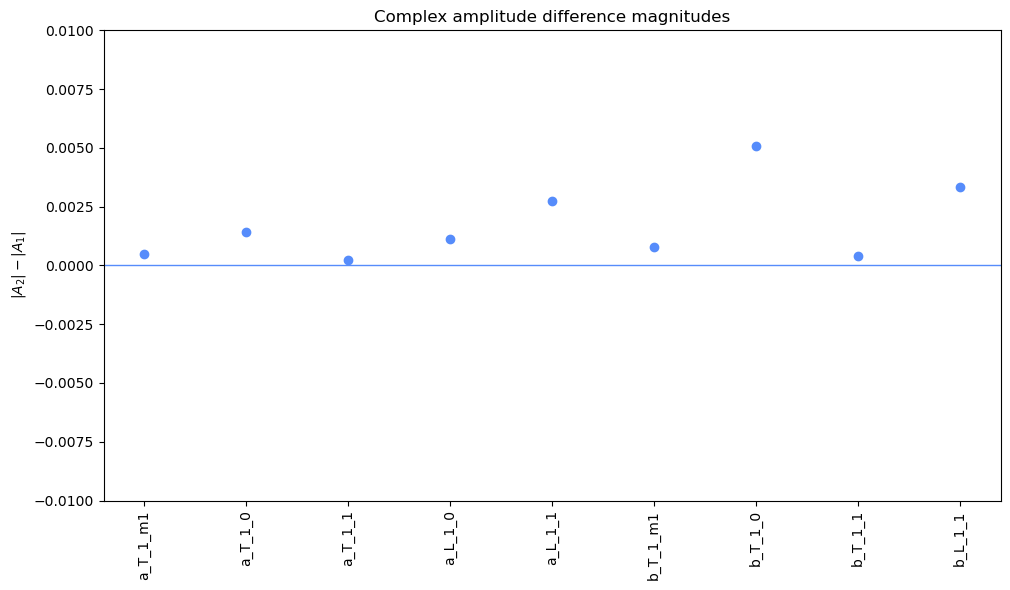

Wrote: amplitude_comparison_output/complex_difference_magnitudes.png


In [632]:
complex_sorted = complex_comparison.sort_values("amplitude", key=lambda s: s.map(sort_amplitude_name)).copy()

x = np.arange(len(complex_sorted))

plt.figure(figsize=(max(10, 0.45 * len(complex_sorted)), 6))
plt.plot(x, complex_sorted["delta_abs"], "o")
plt.xticks(x, complex_sorted["amplitude"], rotation=90)
plt.ylabel(r"$|A_2| - |A_1|$")
plt.title("Complex amplitude difference magnitudes")
plt.axhline(0.0, linewidth=1)
plt.tight_layout()
ax = plt.gca()
ax.set_ylim([-0.01, 0.01])

complex_delta_plot = OUTDIR / "complex_difference_magnitudes.png"
plt.savefig(complex_delta_plot, dpi=200)
plt.show()

print(f"Wrote: {complex_delta_plot}")

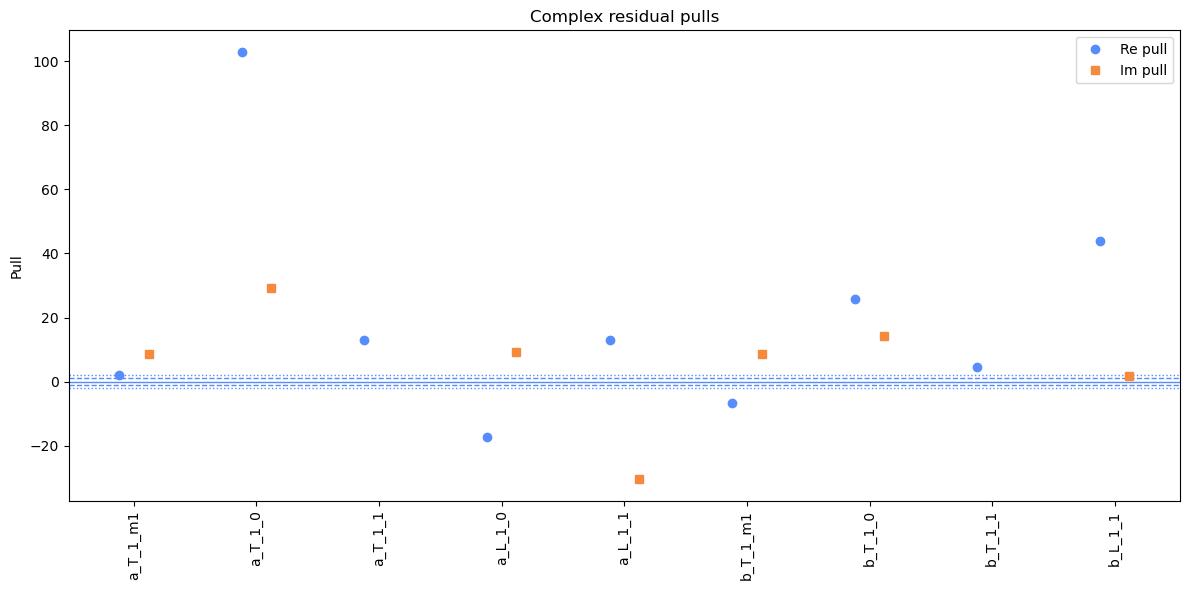

Wrote: amplitude_comparison_output/complex_residual_pulls.png


In [633]:
x = np.arange(len(complex_sorted))

plt.figure(figsize=(max(12, 0.45 * len(complex_sorted)), 6))
plt.axhline(0.0, linewidth=1)
plt.axhline(1.0, linestyle="--", linewidth=1)
plt.axhline(-1.0, linestyle="--", linewidth=1)
plt.axhline(2.0, linestyle=":", linewidth=1)
plt.axhline(-2.0, linestyle=":", linewidth=1)

plt.plot(x - 0.12, complex_sorted["delta_real_pull"], "o", label="Re pull")
plt.plot(x + 0.12, complex_sorted["delta_imag_pull"], "s", label="Im pull")

plt.xticks(x, complex_sorted["amplitude"], rotation=90)
plt.ylabel("Pull")
plt.title("Complex residual pulls")
plt.legend()
plt.tight_layout()

complex_pull_plot = OUTDIR / "complex_residual_pulls.png"
plt.savefig(complex_pull_plot, dpi=200)
plt.show()

print(f"Wrote: {complex_pull_plot}")

## Argand plot of the complex amplitudes

Each amplitude is plotted as a point in the complex plane. The line connects the value from file 1 to the corresponding value from file 2. A long line indicates a large complex change.

In [634]:
def set_equal_argand_axes(ax, x_values, y_values, padding_fraction=0.15):
    x_values = np.asarray(x_values, dtype=float)
    y_values = np.asarray(y_values, dtype=float)

    x_values = x_values[np.isfinite(x_values)]
    y_values = y_values[np.isfinite(y_values)]

    if len(x_values) == 0 or len(y_values) == 0:
        return

    xmin, xmax = np.min(x_values), np.max(x_values)
    ymin, ymax = np.min(y_values), np.max(y_values)

    xmid = 0.5 * (xmin + xmax)
    ymid = 0.5 * (ymin + ymax)

    half_range = max(0.5 * (xmax - xmin), 0.5 * (ymax - ymin), 1e-6)
    half_range *= (1.0 + padding_fraction)

    ax.set_xlim(xmid - half_range, xmid + half_range)
    ax.set_ylim(ymid - half_range, ymid + half_range)
    ax.set_aspect("equal", adjustable="box")

def annotate_argand_points(ax, table, x_col, y_col, label_col="amplitude", max_labels=80):
    # Annotate all points unless the plot is extremely busy.
    if len(table) > max_labels:
        return

    for _, row in table.iterrows():
        x = row[x_col]
        y = row[y_col]
        if np.isfinite(x) and np.isfinite(y):
            ax.annotate(
                row[label_col],
                (x, y),
                textcoords="offset points",
                xytext=(4, 4),
                fontsize=8,
            )

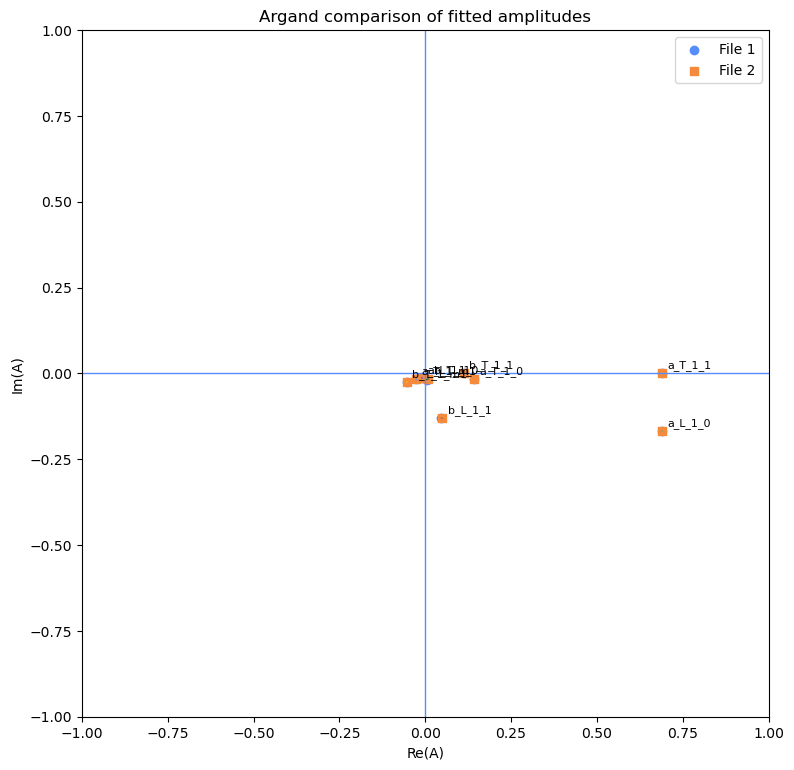

Wrote: amplitude_comparison_output/argand_amplitude_comparison.png


In [635]:
plot_df = complex_sorted.copy()

fig, ax = plt.subplots(figsize=(8, 8))

ax.axhline(0.0, linewidth=1)
ax.axvline(0.0, linewidth=1)

ax.scatter(plot_df["file1_real"], plot_df["file1_imag"], marker="o", label="File 1")
ax.scatter(plot_df["file2_real"], plot_df["file2_imag"], marker="s", label="File 2")

for _, row in plot_df.iterrows():
    x1, y1 = row["file1_real"], row["file1_imag"]
    x2, y2 = row["file2_real"], row["file2_imag"]

    if all(np.isfinite(v) for v in [x1, y1, x2, y2]):
        ax.plot([x1, x2], [y1, y2], linewidth=1)

annotate_argand_points(ax, plot_df, "file2_real", "file2_imag")

all_x = np.concatenate([plot_df["file1_real"].to_numpy(), plot_df["file2_real"].to_numpy()])
all_y = np.concatenate([plot_df["file1_imag"].to_numpy(), plot_df["file2_imag"].to_numpy()])
set_equal_argand_axes(ax, all_x, all_y)

ax.set_xlabel("Re(A)")
ax.set_ylabel("Im(A)")
ax.set_xlim(-1,1)
ax.set_ylim(-1,1)
ax.set_aspect("equal", adjustable="box")
ax.set_title("Argand comparison of fitted amplitudes")
ax.legend()
plt.tight_layout()

argand_plot = OUTDIR / "argand_amplitude_comparison.png"
plt.savefig(argand_plot, dpi=200)
plt.show()

print(f"Wrote: {argand_plot}")

## Argand plot of the complex differences

This plots

\[
\Delta A = A_2 - A_1
\]

for each amplitude. If a point lies near the origin, the two fitted complex amplitudes agree well.

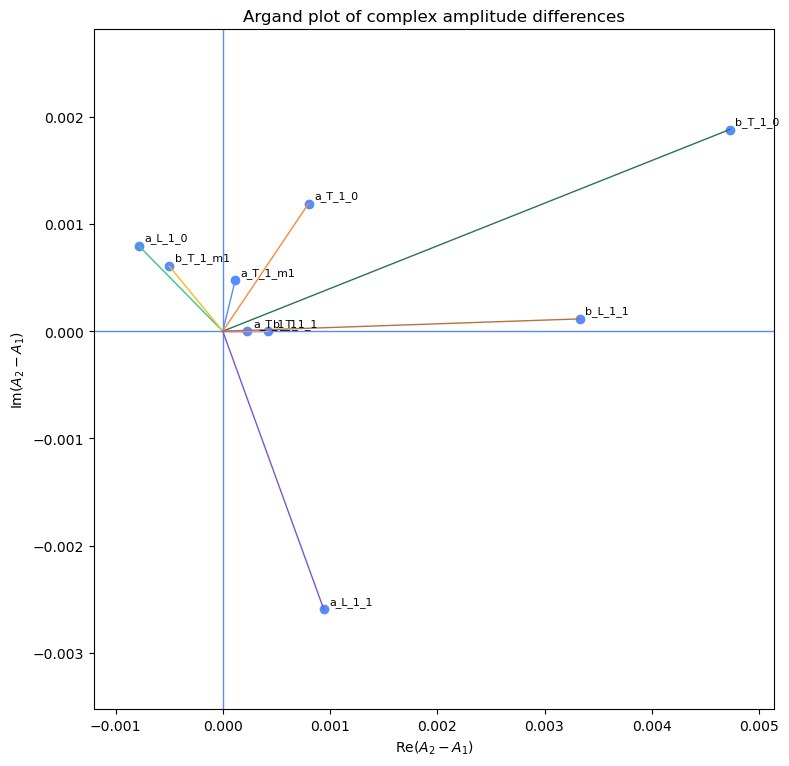

Wrote: amplitude_comparison_output/argand_complex_differences.png


In [636]:
plot_df = complex_sorted.copy()

fig, ax = plt.subplots(figsize=(8, 8))

ax.axhline(0.0, linewidth=1)
ax.axvline(0.0, linewidth=1)

ax.scatter(plot_df["delta_real"], plot_df["delta_imag"], marker="o")

# Lines from origin to each complex residual.
for _, row in plot_df.iterrows():
    dx, dy = row["delta_real"], row["delta_imag"]
    if np.isfinite(dx) and np.isfinite(dy):
        ax.plot([0.0, dx], [0.0, dy], linewidth=1)

annotate_argand_points(ax, plot_df, "delta_real", "delta_imag")

set_equal_argand_axes(ax, plot_df["delta_real"].to_numpy(), plot_df["delta_imag"].to_numpy())

ax.set_xlabel(r"Re($A_2 - A_1$)")
ax.set_ylabel(r"Im($A_2 - A_1$)")
ax.set_title("Argand plot of complex amplitude differences")
plt.tight_layout()

argand_delta_plot = OUTDIR / "argand_complex_differences.png"
plt.savefig(argand_delta_plot, dpi=200)
plt.show()

print(f"Wrote: {argand_delta_plot}")

## Optional: inspect `log_val` distribution before choosing cuts

Run this if you want to see the range of `log_val` values in each file.

In [637]:
def read_log_val_only(path, tree_name=None):
    import ROOT
    path = Path(path)

    f = ROOT.TFile.Open(str(path))
    if not f or f.IsZombie():
        raise OSError(f"Could not open ROOT file: {path}")

    if tree_name is None:
        for key in f.GetListOfKeys():
            obj = key.ReadObj()
            if obj.InheritsFrom("TTree"):
                tree_name = obj.GetName()
                break

    tree = f.Get(tree_name)
    branch_names = [br.GetName() for br in tree.GetListOfBranches()]
    f.Close()

    if "log_val" not in branch_names:
        raise ValueError(f"'log_val' was not found in {path}:{tree_name}")

    rdf = ROOT.RDataFrame(tree_name, str(path))
    arr = rdf.AsNumpy(["log_val"])["log_val"]
    return np.asarray(arr, dtype=float)

# Uncomment to inspect:
# log1 = read_log_val_only(FILE1, TREE1)
# log2 = read_log_val_only(FILE2, TREE2)
#
# print("FILE1 log_val min/median/max:", np.min(log1), np.median(log1), np.max(log1))
# print("FILE2 log_val min/median/max:", np.min(log2), np.median(log2), np.max(log2))
#
# plt.figure(figsize=(8, 5))
# plt.hist(log1, bins=50, alpha=0.5, label="File 1")
# plt.hist(log2, bins=50, alpha=0.5, label="File 2")
# plt.xlabel("log_val")
# plt.ylabel("Entries")
# plt.legend()
# plt.tight_layout()
# plt.show()